In [17]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# %% Load data
DATA_PATH = "data/ElectricMotorTemperature.csv"
df = pd.read_csv(DATA_PATH)

# Drop if present
if 'profile_id' in df.columns:
    df.drop('profile_id', axis=1, inplace=True)

# Quick peek
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print(df.head(3))

# %% Split features/target
target_col = 'torque'
X = df.drop(target_col, axis=1)
y = df[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=SEED
)


Shape: (1330816, 12)
Columns: ['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth', 'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque']
        u_q    coolant  stator_winding       u_d  stator_tooth  motor_speed  \
0 -0.450682  18.805172        19.08667 -0.350055     18.293219     0.002866   
1 -0.325737  18.818571        19.09239 -0.305803     18.294807     0.000257   
2 -0.440864  18.828770        19.08938 -0.372503     18.294094     0.002355   

        i_d       i_q         pm  stator_yoke    ambient    torque  
0  0.004419  0.000328  24.554214    18.316547  19.850691  0.187101  
1  0.000606 -0.000785  24.538078    18.314955  19.850672  0.245417  
2  0.001290  0.000386  24.544693    18.326307  19.850657  0.176615  


X_train_scaled shape: (891646, 11)
y_train_scaled shape: (891646, 1)


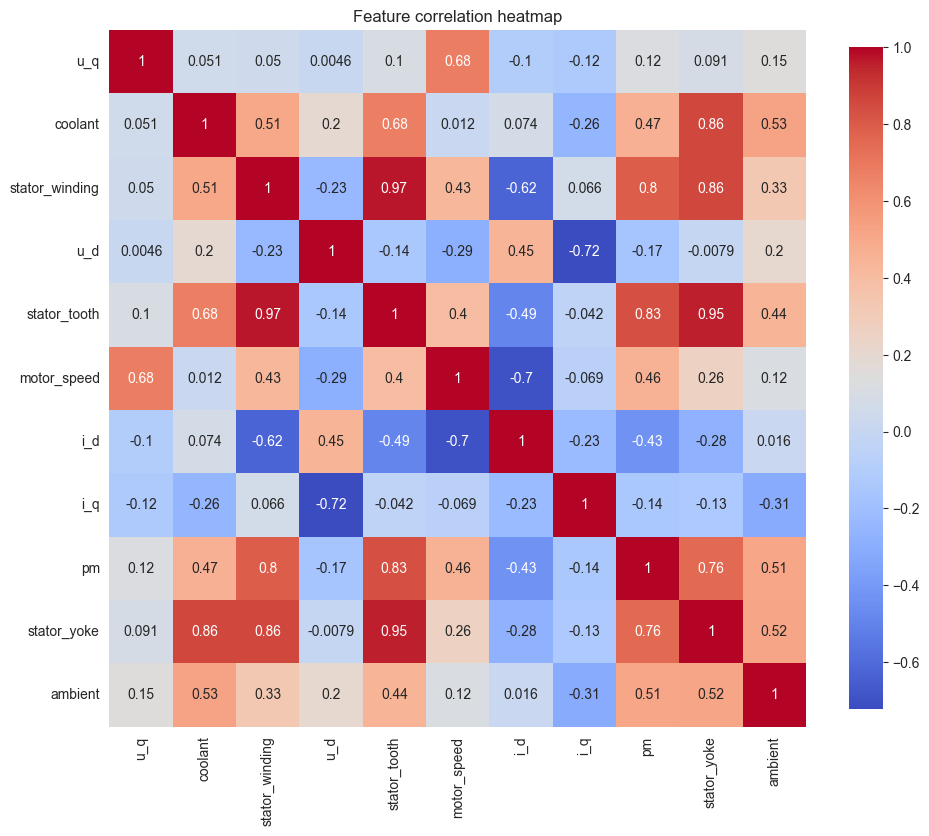

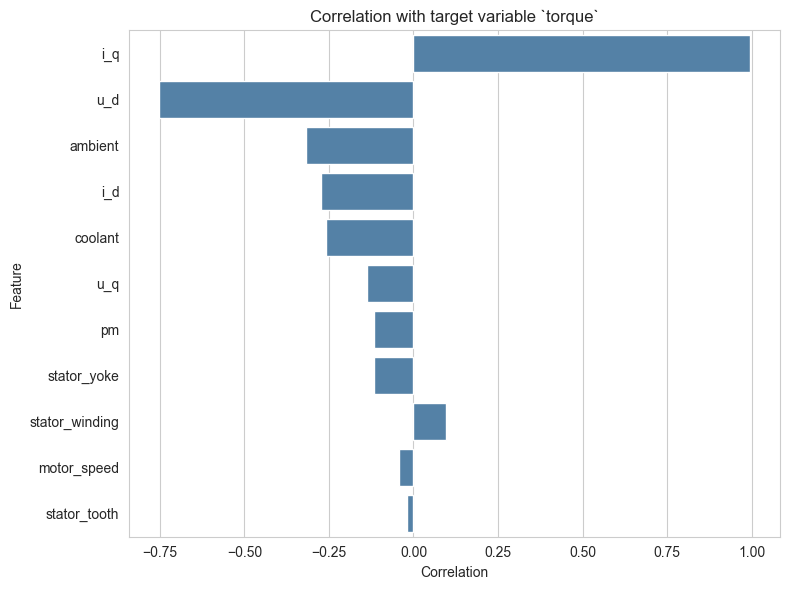

Top correlations: i_q        0.996456
u_d        0.753720
ambient    0.316615
i_d        0.274100
coolant    0.257912
dtype: float64


In [18]:
# %% Scale features and target (use separate scalers for X and y)
x_scaler = StandardScaler()
X_train_scaled = pd.DataFrame(x_scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(x_scaler.transform(X_test), columns=X.columns, index=X_test.index)

y_scaler = StandardScaler()
y_train_scaled = pd.DataFrame(y_scaler.fit_transform(y_train.values.reshape(-1, 1)), columns=[target_col], index=y_train.index)
y_test_scaled = pd.DataFrame(y_scaler.transform(y_test.values.reshape(-1, 1)), columns=[target_col], index=y_test.index)

print('X_train_scaled shape:', X_train_scaled.shape)
print('y_train_scaled shape:', y_train_scaled.shape)

# %% Correlation analysis
plt.figure(figsize=(10, 10))
sns.heatmap(X_train_scaled.corr(), annot=True, cmap='coolwarm', square=True, cbar_kws={'shrink': .7})
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.show()

target_correlation = X_train_scaled.corrwith(y_train_scaled[target_col])
plt.figure(figsize=(8, 6))
order = target_correlation.abs().sort_values(ascending=False).index
sns.barplot(x=target_correlation.loc[order].values, y=order, orient='h', color='steelblue')
plt.title('Correlation with target variable `torque`')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top correlations:', target_correlation.abs().sort_values(ascending=False).head(5))

In [19]:
# %% PyTorch dataset and dataloader
batch_size = 1024
X_tr_tensor = torch.from_numpy(X_train_scaled.values).float()
y_tr_tensor = torch.from_numpy(y_train_scaled.values).float()

train_ds = TensorDataset(X_tr_tensor, y_tr_tensor)
loader = DataLoader(train_ds, shuffle=True, batch_size=batch_size, drop_last=False)

# %% Define model
input_dim = X_train_scaled.shape[1]  # should be 11
model = nn.Sequential(
    nn.Linear(input_dim, 11),
    nn.ReLU(),
    nn.Linear(11, 12),
    nn.ReLU(),
    nn.Linear(12, 5),
    nn.ReLU(),
    nn.Linear(5, 1)
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Sequential(
  (0): Linear(in_features=11, out_features=11, bias=True)
  (1): ReLU()
  (2): Linear(in_features=11, out_features=12, bias=True)
  (3): ReLU()
  (4): Linear(in_features=12, out_features=5, bias=True)
  (5): ReLU()
  (6): Linear(in_features=5, out_features=1, bias=True)
)

In [20]:
# %% Train
n_epochs = 10
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

model.train()
for epoch in range(1, n_epochs + 1):
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_ds)
    print(f'Epoch {epoch:02d}/{n_epochs} - Train MSE (scaled): {epoch_loss:.6f}')


Epoch 01/10 - Train MSE (scaled): 0.883876
Epoch 02/10 - Train MSE (scaled): 0.307944
Epoch 03/10 - Train MSE (scaled): 0.219882
Epoch 04/10 - Train MSE (scaled): 0.182988
Epoch 05/10 - Train MSE (scaled): 0.155963
Epoch 06/10 - Train MSE (scaled): 0.133304
Epoch 07/10 - Train MSE (scaled): 0.114230
Epoch 08/10 - Train MSE (scaled): 0.098456
Epoch 09/10 - Train MSE (scaled): 0.085107
Epoch 10/10 - Train MSE (scaled): 0.073298


In [21]:
# %% Evaluate
model.eval()
with torch.no_grad():
    X_te_tensor = torch.from_numpy(X_test_scaled.values).float().to(device)
    y_te_tensor = torch.from_numpy(y_test_scaled.values).float().to(device)
    y_pred_scaled = model(X_te_tensor).cpu().numpy()

test_mse_scaled = float(nn.MSELoss()(torch.tensor(y_pred_scaled), torch.tensor(y_test_scaled.values)).item())
r2_scaled = r2_score(y_test_scaled.values.reshape(-1, 1), y_pred_scaled.reshape(-1, 1))

print(f'Loss on test data (scaled MSE) = {test_mse_scaled:.12f}')
print(f'R`2` score on test data (scaled) = {r2_scaled:.12f}')

# Optionally inverse-transform predictions to original units
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1, 1)
test_mse_real = float(nn.MSELoss()(
    torch.tensor(y_pred), torch.tensor(y_test.values.reshape(-1, 1))).item())
r2_real = r2_score(y_test.values.reshape(-1, 1), y_pred.reshape(-1, 1))
print(f'Loss on test data (real-unit MSE) = {test_mse_real:.6f}')
print(f'R`2` score on test data (real units) = {r2_real:.6f}')

Loss on test data (scaled MSE) = 0.067194924564
R`2` score on test data (scaled) = 0.932783518293
Loss on test data (real-unit MSE) = 399.846695
R`2` score on test data (real units) = 0.932784


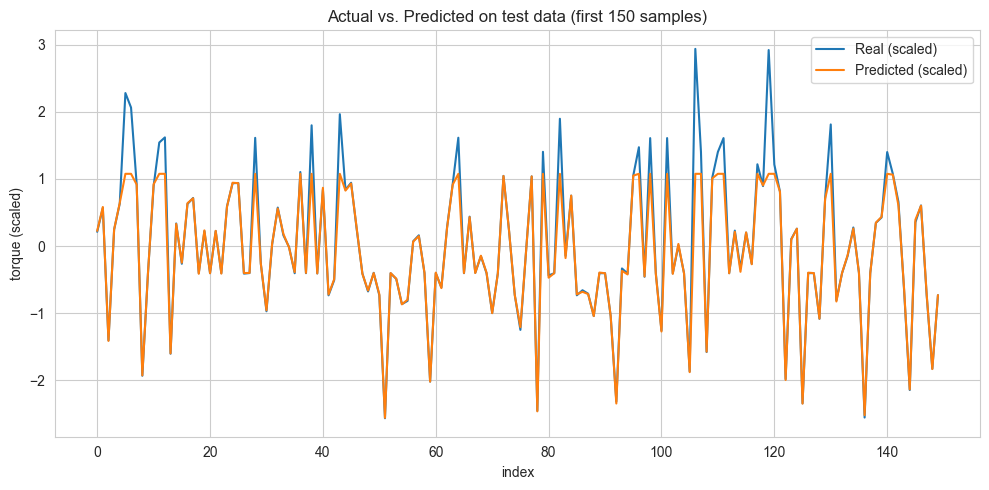

In [22]:
# %% Plot actual vs predicted (first n samples) in scaled space
n_sample = 150
test_sample = y_test_scaled.values.reshape(-1, 1)[:n_sample]
predicted_sample = y_pred_scaled.reshape(-1, 1)[:n_sample]

plt.figure(figsize=(10, 5))
plt.plot(range(len(test_sample)), test_sample, label='Real (scaled)')
plt.plot(range(len(predicted_sample)), predicted_sample, label='Predicted (scaled)')
plt.xlabel('index')
plt.ylabel('torque (scaled)')
plt.legend()
plt.title(f'Actual vs. Predicted on test data (first {n_sample} samples)')
plt.tight_layout()
plt.show()

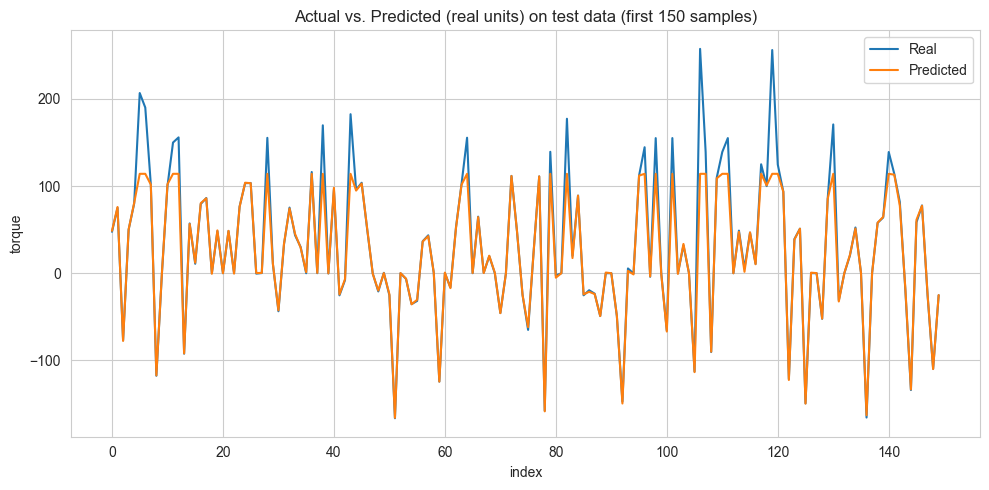

In [23]:
# %% Plot actual vs predicted (first n samples) in real units
test_sample_real = y_test.values.reshape(-1, 1)[:n_sample]
predicted_sample_real = y_pred.reshape(-1, 1)[:n_sample]

plt.figure(figsize=(10, 5))
plt.plot(range(len(test_sample_real)), test_sample_real, label='Real')
plt.plot(range(len(predicted_sample_real)), predicted_sample_real, label='Predicted')
plt.xlabel('index')
plt.ylabel('torque')
plt.legend()
plt.title(f'Actual vs. Predicted (real units) on test data (first {n_sample} samples)')
plt.tight_layout()
plt.show()

In [25]:
# %% ACPI Implementation
from acpi import ACPI
from acpi.utils import compute_coverage

# Split test set into calibration and ACPI test sets
cal_size = 0.5
n_cal = int(len(X_test_scaled) * cal_size)

X_cal = X_test_scaled.values[:n_cal]
X_test_acpi = X_test_scaled.values[n_cal:]
y_cal = y_test_scaled.values[:n_cal].reshape(-1)
y_test_acpi = y_test_scaled.values[n_cal:].reshape(-1)

print(f"Calibration set size: {len(X_cal)}")
print(f"ACPI Test set size: {len(X_test_acpi)}")


class PyTorchACPIWrapper:
    """ACPI wrapper for PyTorch model."""

    def __init__(self, model, device):
        self.model = model
        self.device = device

    def predict(self, X):
        """Predict using the PyTorch model."""
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.from_numpy(X).float().to(self.device)
            predictions = self.model(X_tensor).cpu().numpy().reshape(-1)
        return predictions


# Wrap the trained PyTorch model
pytorch_wrapper = PyTorchACPIWrapper(model, device)

Calibration set size: 219585
ACPI Test set size: 219585


In [28]:
# %% Initialize and fit ACPI
alpha = 0.1
acpi_model = ACPI(
    model_cali=pytorch_wrapper,
    n_estimators=100,
    max_depth=10,
    min_node_size=15
)

print("\nFitting ACPI model...")
acpi_model.fit(X_cal, y_cal)
acpi_model.fit_calibration(X_cal, y_cal, quantile=(1 - alpha), only_qrf=True)
print("ACPI fitting complete.")

# Generate prediction intervals
y_lower, y_upper = acpi_model.predict_pi(X_test_acpi, method="qrf")

# Evaluate coverage
coverage = compute_coverage(y_test_acpi, y_lower, y_upper)
print(f"\nACPI Coverage: {coverage:.4f} (Target: {1-alpha:.4f})")

# Get point predictions for comparison
y_pred_acpi = pytorch_wrapper.predict(X_test_acpi)


Fitting ACPI model...


100%|██████████| 50/50 [1:33:17<00:00, 111.95s/it]


ACPI fitting complete.

ACPI Coverage: 0.9064 (Target: 0.9000)


In [29]:
# save the model
MODEL_PATH = "models/pytorch_motor_torque_acpi.pth"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to models/pytorch_motor_torque_acpi.pth


In [31]:
import joblib

# Save the ACPI model and wrapper
ACPI_MODEL_PATH = "models/acpi_motor_torque_model.pkl"
os.makedirs(os.path.dirname(ACPI_MODEL_PATH), exist_ok=True)

# Save both the ACPI model and the PyTorch wrapper
acpi_save_dict = {
    'acpi_model': acpi_model,
    'pytorch_wrapper': pytorch_wrapper,
    'scaler_x': x_scaler,
    'scaler_y': y_scaler,
    'feature_names': X.columns.tolist(),
    'target_name': target_col
}

joblib.dump(acpi_save_dict, ACPI_MODEL_PATH)
print(f"ACPI model saved to {ACPI_MODEL_PATH}")

ACPI model saved to models/acpi_motor_torque_model.pkl
